--- [EDA] Data Exploration & Visualization ---


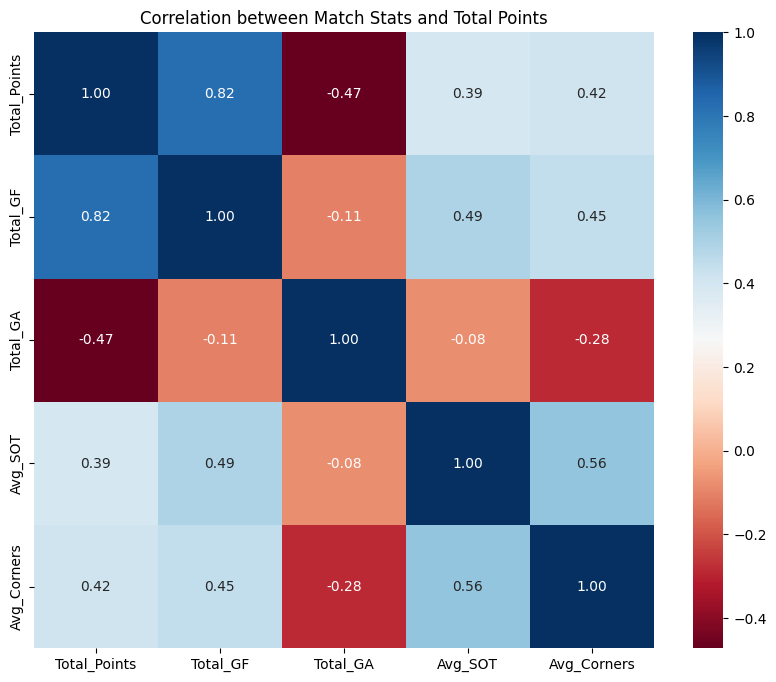

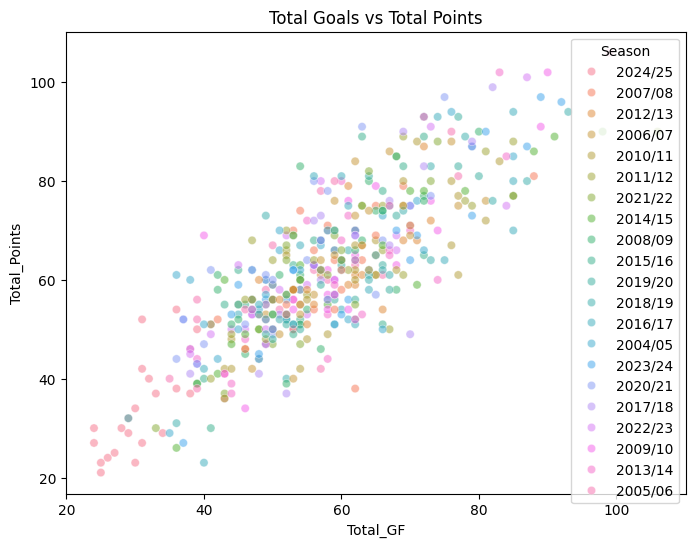


--- [ML] Supervised Learning: Regression Modeling ---
MLR Model Accuracy (R-squared): 0.9026

--- [Prediction] 2024/25 Season Promotion Candidates ---
                 Team  Total_Points  Predicted_Points
21              Leeds            53         81.903136
43            Burnley            52         78.239040
0    Sheffield United            54         76.090336
65         Sunderland            50         74.601310
132         West Brom            40         70.704714


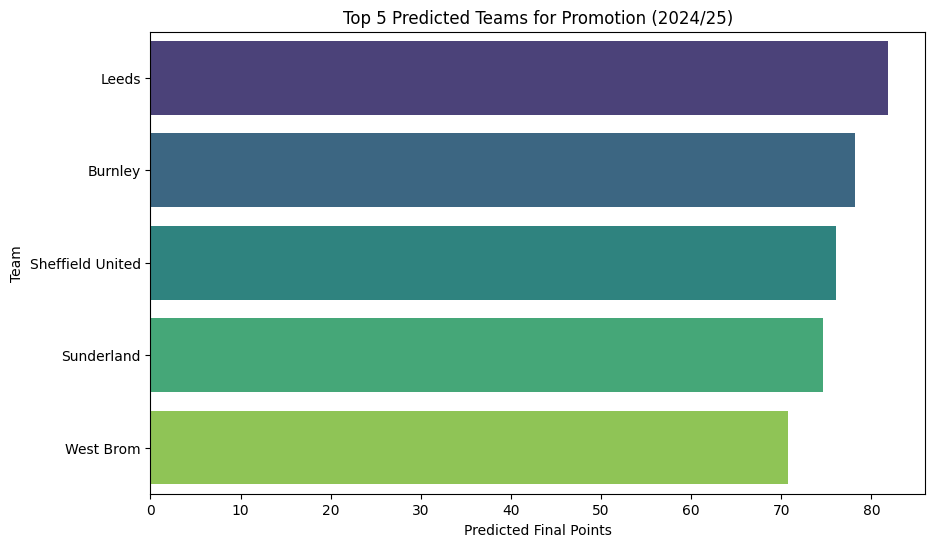

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# 1. Load Data
# Path to the processed seasonal statistics CSV
file_path = r'efl_promotion_teams - seasonal_stats.csv'
df = pd.read_csv(file_path)

# --- PART 1: EDA (Exploratory Data Analysis) ---
print("--- [EDA] Data Exploration & Visualization ---")

# (1) Correlation Heatmap: Identifying the strongest drivers of points
plt.figure(figsize=(10, 8))
corr = df[['Total_Points', 'Total_GF', 'Total_GA', 'Avg_SOT', 'Avg_Corners']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation between Match Stats and Total Points')
plt.show()

# (2) Scatter Plot: Visualizing the relationship between Goals and Points
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Total_GF', y='Total_Points', hue='Season', alpha=0.5)
plt.title('Total Goals vs Total Points')
plt.show()

# --- PART 2: Machine Learning (Supervised Learning) ---
print("\n--- [ML] Supervised Learning: Regression Modeling ---")

# Split data: Train on past seasons, Predict on the current 2024/25 season
train_df = df[df['Season'] != '2024/25'].dropna()
test_df = df[df['Season'] == '2024/25'].dropna()

# Define Independent Variables (Features) and Dependent Variable (Target)
features = ['Total_GF', 'Total_GA', 'Avg_SOT', 'Avg_Corners']
X_train = train_df[features]
y_train = train_df['Total_Points']

# 2-1. Train Multiple Linear Regression (MLR) Model
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# 2-2. Evaluate Model Performance (R-squared)
mlr_r2 = r2_score(y_train, mlr.predict(X_train))
print(f"MLR Model Accuracy (R-squared): {mlr_r2:.4f}")

# --- PART 3: Prediction (Forecasting 2024/25 Standings) ---
print("\n--- [Prediction] 2024/25 Season Promotion Candidates ---")

# Apply the model to current season stats
test_df['Predicted_Points'] = mlr.predict(test_df[features])

# Sort and display the Top 5 predicted teams
top_teams = test_df.sort_values('Predicted_Points', ascending=False).head(5)
print(top_teams[['Team', 'Total_Points', 'Predicted_Points']])

# Visualize Final Predictions
plt.figure(figsize=(10, 6))
sns.barplot(data=top_teams, x='Predicted_Points', y='Team', palette='viridis', hue='Team', legend=False)
plt.title('Top 5 Predicted Teams for Promotion (2024/25)')
plt.xlabel('Predicted Final Points')
plt.show()